In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from rouge_score import rouge_scorer

from src.data_utils import (
    read_dataset, clean_text, show_statistics, clean_short_tweet, save_dataset,
    split_data, tokenize_texts)
from src.next_token_dataset import AutocompleteDataset, collate_fn
from src.lstm_model import AutocompleteLSTM
from src.lstm_train import train_epoch
from src.eval_lstm import evaluate_token_accuracy, evaluate_rouge, show_autocomplete
from src.eval_transformer_pipeline import evaluate_rouge_transformer, show_autocomplete_transformer
from src.utils import get_config

d:\TRAININGS\DL\Sprint_2_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = get_config("./configs/config.yaml")

Конфигурационные данные успешно загружены.


## Загрузка и подготовка данных

Загрузим исходный датасет твиттов:

In [3]:
df = read_dataset(config["raw_dataset_path"])

Количество записей в датасете: 1600498

Первая запись из датасета:
@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

                                               tweet
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1  is upset that he can't update his Facebook by ...
2  @Kenichan I dived many times for the ball. Man...
3     my whole body feels itchy and like its on fire
4  @nationwideclass no, it's not behaving at all....


Записи содержат хештеги, адреса сайтов, обращения к пользователям (@user) и прочие лишние символы - проведем очистку датасета от этих данных.

In [4]:
texts = [clean_text(text) for text in df['tweet'].tolist()]
texts[:10]

['awww thats a bummer you shoulda got david carr of third day to do it d',
 'is upset that he cant update his facebook by texting it and might cry as a result school today also blah',
 'i dived many times for the ball managed to save 50 the rest go out of bounds',
 'my whole body feels itchy and like its on fire',
 'no its not behaving at all im mad why am i here because i cant see you all over there',
 'not the whole crew',
 'need a hug',
 'hey long time no see yes rains a bit only a bit lol im fine thanks hows you',
 'nope they didnt have it',
 'que me muera']

Записи содержат от 0 до 40 слов, причем существенное большинство из них приходятся на диапозон из 4 до 15 слов. Средняя длина записей - 12,5, медиана чуть ниже - 11.


Статистика по количеству слов в тексте:
Среднее: 12.47
Медиана: 11.00
Минимальное: 0.00
Максимальное: 40.00
5-й перцентиль: 3.00
95-й перцентиль: 25.00


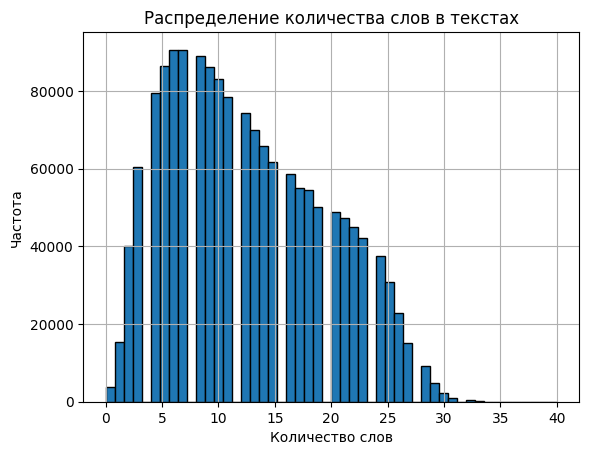

Топ-20 самых популярных слов в текстах:
[('i', 751135), ('to', 564692), ('the', 520264), ('a', 378269), ('my', 314141), ('and', 298493), ('you', 270168), ('is', 236130), ('it', 230937), ('for', 215775), ('in', 214280), ('of', 183492), ('im', 178382), ('on', 167129), ('me', 160120), ('so', 150817), ('have', 144550), ('that', 141372), ('but', 127501), ('just', 125100)]
Количество уникальных слов: 433354


In [5]:
show_statistics(texts)

Удалим самые короткие записи: от пустых (0 слов) до 5 перцентиля (3 слова):

In [6]:
texts = clean_short_tweet(texts, min_text_lenght=3)
print(f"Количество записей в датасете: {len(texts)}")
print(f"% от первоначального кол-ва записей: {round(len(texts) / df.shape[0] * 100, 2)}%")

Количество записей в датасете: 1541143
% от первоначального кол-ва записей: 96.29%


In [7]:
# сокращенная версия датасета для отладки кода проекта локально
debug = config["debug"]
if debug:
	debug_version_dataset_size = config["debug_version_dataset_size"]
	texts = texts[:debug_version_dataset_size]

Сохраним очищенный датасет:

In [8]:
save_dataset(texts, config["clean_dataset_path"])

Файл clean_dataset.csv успешно сохранен


Разделим датасет на 3 подвыборки:
- обучающую (80%)
- валидационнцю (10%)
- тестовую (10%)

In [9]:
train, val, test = split_data(
    texts,
    config["val_size"],
    config["test_size"],
    config["random_state"]
)

Обучающая выборка: 800 записей
Валидационная выборка: 100 записей
Тестовая выборка: 100 записей


In [10]:
save_dataset(train, config["train_dataset_path"])
save_dataset(val, config["val_dataset_path"])
save_dataset(test, config["test_dataset_path"])

Файл train_dataset.csv успешно сохранен
Файл val_dataset.csv успешно сохранен
Файл test_dataset.csv успешно сохранен


## Подготовка Dataloader'ов

Токенизируем тексты из всех выборок.\
В рамках проекта выбран токенизатор distilgpt2, поскольку задание предполагает использование во второй части трансформера distilgpt2,\
что делает логичным выбор токенизатора, который подойдет как для LSTM модели, так и для указанного трансформера.

In [11]:
tokenizer = AutoTokenizer.from_pretrained(config["tokenizer_model_name"])
if tokenizer.pad_token is None:
	tokenizer.pad_token = tokenizer.eos_token

tokenized_train = tokenize_texts(train, tokenizer)
tokenized_val = tokenize_texts(val, tokenizer)
tokenized_test = tokenize_texts(test, tokenizer)

Подготовим датасеты:

In [12]:
train_dataset = AutocompleteDataset(tokenized_train)
val_dataset = AutocompleteDataset(tokenized_val)
test_dataset = AutocompleteDataset(tokenized_test)

In [13]:
train_dataset[0]

{'text': tensor([ 1326,    71,  2048, 18854,   318,   262,  6631,   428,  2610,  3011,
           502, 19095,   790]),
 'answer': tensor([   71,  2048, 18854,   318,   262,  6631,   428,  2610,  3011,   502,
         19095,   790,   640])}

Создадим загрузчики данных (dataloaders), дополнив последовательности пэддингом и приведя их к единому размеру:

In [14]:
batch_size = config['batch_size']
padding = tokenizer.pad_token_id

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=lambda batch: collate_fn(batch, padding)
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, padding)
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, padding)
)

In [15]:
print(f'Количество батчей в train_dataloader: {len(train_dataloader)}')
print(f'Количество батчей в val_dataloader: {len(val_dataloader)}')
print(f'Количество батчей в test_dataloader: {len(test_dataloader)}')

Количество батчей в train_dataloader: 7
Количество батчей в val_dataloader: 1
Количество батчей в test_dataloader: 1


In [16]:
print('Размерности батчей:')
for batch in train_dataloader:
    print('texts:', batch['texts'].shape)
    print('answers:', batch['answers'].shape)
    print('\nПример батча:')
    print(batch)
    break

Размерности батчей:
texts: torch.Size([128, 33])
answers: torch.Size([128, 33])

Пример батча:
{'texts': tensor([[   72,  1807,   345,  ..., 50256, 50256, 50256],
        [   67,   648,  1194,  ..., 50256, 50256, 50256],
        [11274,  1108,   502,  ..., 50256, 50256, 50256],
        ...,
        [19554,  1130,  1359,  ..., 50256, 50256, 50256],
        [   72,   481,  4043,  ..., 50256, 50256, 50256],
        [ 4360,   644,  1312,  ..., 50256, 50256, 50256]]), 'answers': tensor([[ 1807,   345,   561,  ..., 50256, 50256, 50256],
        [  648,  1194,  6076,  ..., 50256, 50256, 50256],
        [ 1108,   502,   703,  ..., 50256, 50256, 50256],
        ...,
        [ 1130,  1359,  1327,  ..., 50256, 50256, 50256],
        [  481,  4043,   329,  ..., 50256, 50256, 50256],
        [  644,  1312,  1107,  ..., 50256, 50256, 50256]]), 'lengths': tensor([ 7, 28, 24, 22, 20, 23, 16, 17, 20,  8, 17,  6, 17, 14, 13,  7,  9, 25,
         9,  5, 13,  7, 27, 11, 33, 18,  5, 13,  6,  6, 10, 11,  4,

## LSTM

Определим доступное устройство:

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Создадим LSTM модель, используя кастомный класс AutocompleteLSTM.\
Метод foreward модели предсказывает следующий токен, а метод generate - генерирует последовательность токенов.

In [18]:
# создание модели
model = AutocompleteLSTM(
    vocab_size=tokenizer.vocab_size,
    embed_dim=config["embed_dim"],
    hidden_dim=config["hidden_dim"],
    pad_idx=tokenizer.pad_token_id,
    dropout=config["dropout"]
).to(device)

Для удобства и лаконичности передачи данных в функции создадим словарь с ключевыми параметрами:
- устройство
- оптимизатор
- функция потерь
- клиппинг градиентов
- токенизатор

Они понадобится при обучении и оценке моделей.

In [19]:
params = {
    'device': device,
	'optimizer': torch.optim.Adam(model.parameters(), lr=float(config["lr"])),
	'criterion': nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id),
	'grad_clipping': config["grad_clipping"],
	'tokenizer': tokenizer,
	'split_ratio': config["rouge_split_ratio"],
    'max_new_tokens': config["max_new_tokens"]
}

Для оценки качества модели воспользуемся метрикой ROUGE и применим ее следующим образом:\
в качестве входа модель получает 3/4 исходного текста и старается дополнить оставшиеся 1/4.

In [20]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=True)

Проведем обучение модели.\
В качестве метрик эпох обучения будем выводить Loss и token-level Accuracy (т.е. долю правильно предсказанных токенов).\
Для валидационной выборки также рассчитаем ROUGE.

!!! Удалить уменьшение кол-ва!!!!

In [21]:
for epoch in range(config["n_epochs"]):
    train_loss, train_acc = train_epoch(model, train_dataloader, params)
    val_loss, val_acc = evaluate_token_accuracy(model, val_dataloader, params)
    rouge1, rouge2 = evaluate_rouge(model, tokenized_val[:100], scorer, params)
    print(f"Epoch: {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")
    print("=" * 50)


100%|██████████| 100/100 [00:20<00:00,  4.83it/s]


Epoch: 1
Train Loss: 10.6936 | Train Acc: 0.0127
Val Loss:   10.1533 | Val Acc:   0.0337
ROUGE-1: 0.0015 | ROUGE-2: 0.0000


100%|██████████| 100/100 [00:21<00:00,  4.59it/s]


Epoch: 2
Train Loss: 8.6544 | Train Acc: 0.0362
Val Loss:   7.9847 | Val Acc:   0.0284
ROUGE-1: 0.0159 | ROUGE-2: 0.0000


100%|██████████| 100/100 [00:21<00:00,  4.64it/s]


Epoch: 3
Train Loss: 7.2093 | Train Acc: 0.0315
Val Loss:   8.1021 | Val Acc:   0.0268
ROUGE-1: 0.0302 | ROUGE-2: 0.0000


100%|██████████| 100/100 [00:21<00:00,  4.56it/s]


Epoch: 4
Train Loss: 7.0158 | Train Acc: 0.0314
Val Loss:   8.1757 | Val Acc:   0.0276
ROUGE-1: 0.0201 | ROUGE-2: 0.0000


100%|██████████| 100/100 [00:20<00:00,  4.89it/s]

Epoch: 5
Train Loss: 6.8947 | Train Acc: 0.0313
Val Loss:   8.2592 | Val Acc:   0.0253
ROUGE-1: 0.0191 | ROUGE-2: 0.0000


In [22]:
show_autocomplete(model, tokenized_val, config['n_samples'], params)

Полный исходный текст      : gotta do my cooking assignment its too hard
Полный предсказанный текст : gotta do my cooking assignment fuck film starts whus help placeuss pet is the thingian men editing could to idea how mur o sh through forward the a fri freelance sigh u

Часть для дополнения       : gotta do my cooking assignment
Правильный ответ           :  its too hard
Предсказанный ответ        :  fuck film starts whus help placeuss pet is the thingian men editing could to idea how mur o sh through forward the a fri freelance sigh u
Полный исходный текст      : just finished watching the movie prayers for bobby broke my heart
Полный предсказанный текст : just finished watching the movie prayers for bobby out some t out we darn sleep is become lo tried ratherunct somewhere am year the and start out justi les is havef want time te

Часть для дополнения       : just finished watching the movie prayers for bobby
Правильный ответ           :  broke my heart
Предсказанный ответ        : 

Рассчитаем метрики ROUGE для LSTM на тестовых данных:

In [23]:
rouge1, rouge2 = evaluate_rouge(model, tokenized_test, scorer, params)
print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")


100%|██████████| 100/100 [00:21<00:00,  4.70it/s]

ROUGE-1: 0.0211 | ROUGE-2: 0.0000


Также посмотрим на дополненные моделью тексты из тестовых данных:

In [24]:
show_autocomplete(model, tokenized_test, config['n_samples'], params)

Полный исходный текст      : cant believe it im in disbelief of it all in a way really how much can i take from people and always get hurt by others
Полный предсказанный текст : cant believe it im in disbelief of it all in a way really how much can i take from languages will im dislike the a you weekend cam my ra see seriouslyliningml to and badil but hope i running spilled not is forgot ugly to

Часть для дополнения       : cant believe it im in disbelief of it all in a way really how much can i take from
Правильный ответ           :  people and always get hurt by others
Предсказанный ответ        :  languages will im dislike the a you weekend cam my ra see seriouslyliningml to and badil but hope i running spilled not is forgot ugly to
Полный исходный текст      : who turned the lights on it will be time to get ip then
Полный предсказанный текст : who turned the lights on it will be timear awesome he to the so tired not that w written mar left ve right behind and youada sad is cam did

## Transformers

Загрузим предобученную модель трансформер distilgpt2 и оценим результаты работы данной модели на той же выборке


In [25]:
model_transformer = AutoModelForCausalLM.from_pretrained(config["transformer_model_name"]).to(device)
model_transformer.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [26]:
# tokenized_val = tokenized_val[:10]

Подготовим словарь параметров для дальнейшего удобства передачи в функции:

In [27]:
transformer_params = {
    'device': device,
	'tokenizer': tokenizer,
	'split_ratio': config["rouge_split_ratio"],
    'max_new_tokens': config["max_new_tokens"],
    'temperature': config["temperature"],
    'top_k': config["top_k"]
}

Рассчитаем метрики ROUGE для Трансформера на валидационных данных:

In [28]:
rouge1, rouge2 = evaluate_rouge_transformer(model_transformer, tokenized_val, scorer, transformer_params)
print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")

100%|██████████| 100/100 [01:14<00:00,  1.35it/s]

ROUGE-1: 0.0331 | ROUGE-2: 0.0030


А также посмотрим на примеры дополненных моделью фраз:

In [29]:
n_samples = config['n_samples']

In [30]:
show_autocomplete_transformer(
    model_transformer,
    tokenized_val,
    n_samples,
    transformer_params,
)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : gotta do my cooking assignment its too hard
Полный предсказанный текст : gotta do my cooking assignment.

I’m not sure if I’m going to be able to do it.
I’m not sure if

Часть для дополнения       : gotta do my cooking assignment
Правильный ответ           :  its too hard
Предсказанный ответ        : .

I’m not sure if I’m going to be able to do it.
I’m not sure if


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : just finished watching the movie prayers for bobby broke my heart
Полный предсказанный текст : just finished watching the movie prayers for bobby.






























Часть для дополнения       : just finished watching the movie prayers for bobby
Правильный ответ           :  broke my heart
Предсказанный ответ        : .































The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : awww so sad im so sorry
Полный предсказанный текст : awww so sad im going to be in the hospital for a while.





















Часть для дополнения       : awww so sad im
Правильный ответ           :  so sorry
Предсказанный ответ        :  going to be in the hospital for a while.






















The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : keeeerrrrriiiiii i really have nothing better to do then post on this thing at 224amwonderfullll says alot
Полный предсказанный текст : keeeerrrrriiiiii i really have nothing better to do then post on this thing at 224.






























Часть для дополнения       : keeeerrrrriiiiii i really have nothing better to do then post on this thing at 224
Правильный ответ           : amwonderfullll says alot
Предсказанный ответ        : .





























Полный исходный текст      : omg exams killed me how could i not know the difference between haif a circle and a hemisphere lt3 gt
Полный предсказанный текст : omg exams killed me how could i not know the difference between haif a circle and a circle.

I was a little bit surprised when I saw the picture of the circle.
I was surprised when I saw the picture of

Часть для дополнения       : omg exams killed me how could i not know the difference between haif a circle and
Правильный ответ     

Посмотрим на эти же показатели, но на тестовых данных:

In [31]:
rouge1, rouge2 = evaluate_rouge_transformer(model_transformer, tokenized_test, scorer, transformer_params)
print(f"ROUGE-1: {rouge1:.4f} | ROUGE-2: {rouge2:.4f}")

100%|██████████| 100/100 [01:12<00:00,  1.37it/s]

ROUGE-1: 0.0575 | ROUGE-2: 0.0156


In [32]:
show_autocomplete_transformer(
    model_transformer,
    tokenized_test,
    n_samples,
    transformer_params
)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : cant believe it im in disbelief of it all in a way really how much can i take from people and always get hurt by others
Полный предсказанный текст : cant believe it im in disbelief of it all in a way really how much can i take from the fact that i am a man.























Часть для дополнения       : cant believe it im in disbelief of it all in a way really how much can i take from
Правильный ответ           :  people and always get hurt by others
Предсказанный ответ        :  the fact that i am a man.
























The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : who turned the lights on it will be time to get ip then
Полный предсказанный текст : who turned the lights on it will be time to get the lights back on.”

Часть для дополнения       : who turned the lights on it will be time
Правильный ответ           :  to get ip then
Предсказанный ответ        :  to get the lights back on.”


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : i love you buck
Полный предсказанный текст : i love you.






























Часть для дополнения       : i love you
Правильный ответ           :  buck
Предсказанный ответ        : .































The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Полный исходный текст      : i miss my ps3 its out of commission wutcha playing have you copped blood on the sand
Полный предсказанный текст : i miss my ps3 its out of commission wutcha playing have you guys been playing with me for a while now?





















Часть для дополнения       : i miss my ps3 its out of commission wutcha playing have you
Правильный ответ           :  copped blood on the sand
Предсказанный ответ        :  guys been playing with me for a while now?




















Полный исходный текст      : oh i thought the pirate bay trial verdict was today s apparently its in 10 days
Полный предсказанный текст : oh i thought the pirate bay trial verdict was today s apparently a good one.



























Часть для дополнения       : oh i thought the pirate bay trial verdict was today s apparently
Правильный ответ           :  its in 10 days
Предсказанный ответ        :  a good one.


























